In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import torch
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.cm as cm

device = "cuda" if torch.cuda.is_available() else "cpu"

# where my preprocessed NSD files live
nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
data_folder = os.path.join(nsd_path, 'data')
labels_folder = os.path.join(nsd_path, 'labels')
stim_folder = os.path.join(nsd_path, 'stimuli')
rois_folder = os.path.join(nsd_path, 'rois')

# where the model fits are saved and loaded from:
save_fits_folder = '/lab_data/hendersonlab/projects/eccbias/model_fits/'

sys.path.append('/lab_data/hendersonlab/code/utils/')
import stats_utils

In [2]:
figpath = '/lab_data/hendersonlab/projects/eccbias/figures/'
if not os.path.exists(figpath):
    os.makedirs(figpath)

plt.rcParams['pdf.fonttype']=42


In [3]:
subjects = np.arange(1, 9)

model1_name = 'resnet18-PeriphNonTTM'
model2_name = 'resnet18-PeriphTTM'

model_names = ['varpart_%s_vs_%s'%(model1_name, model2_name)]

model1_short = 'PeriphNonTTM'
model2_short = 'PeriphTTM'

fits = dict([])

for name in model_names:

    fits[name] = dict([])

    for si, ss in enumerate(subjects):

        name_short = name.split('_block')[0]
        name_short = name_short.split('_concat')[0]
        save_folder = os.path.join(save_fits_folder, name_short)
        filename = os.path.join(save_folder, 'NSD_S%d_%s.npy'%(ss, name))
        print(filename)
        readable_time = datetime.fromtimestamp(os.path.getmtime(filename)).strftime('%B %d, %Y at %I:%M %p')
        print(f"Last modified: {readable_time}")
        fit = np.load(filename, allow_pickle=True).item()

        # computing unique variance explained
        varpart_model_names = fit['r2_varpart'].keys()
        fit['varpart_model_names'] = varpart_model_names

        r2_model1_only = fit['r2_varpart']['%s-only'%(model1_name)]
        r2_model2_only = fit['r2_varpart']['%s-only'%(model2_name)]
        r2_combined = fit['r2_varpart']['combined']
        fit['model1_only'] = r2_model1_only
        fit['model2_only'] = r2_model2_only

        # unique var is difference between combined and each solo model
        unique1 = r2_combined - r2_model2_only
        unique2 = r2_combined - r2_model1_only
        # shared var is the difference between combined and total unique
        shared = r2_combined - unique1 - unique2
        
        fit['unique1'] = unique1
        fit['unique2'] = unique2
        fit['shared'] = shared
    
        fits[name][ss] = fit

/lab_data/hendersonlab/projects/eccbias/model_fits/varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM/NSD_S1_varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM.npy
Last modified: February 11, 2026 at 07:20 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM/NSD_S2_varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM.npy
Last modified: February 11, 2026 at 07:25 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM/NSD_S3_varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM.npy
Last modified: February 11, 2026 at 07:27 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM/NSD_S4_varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM.npy
Last modified: February 11, 2026 at 07:29 PM
/lab_data/hendersonlab/projects/eccbias/model_fits/varpart_resnet18-PeriphNonTTM_vs_resnet18-PeriphTTM/NSD_S5_varpart_resnet18-PeriphNonTTM_vs_resnet18-Peri

In [4]:
vox_floc_tstats = dict([])
for subject in subjects:
    fn = os.path.join(rois_folder, 'S%d_floc_tstats.npy'%subject)
    tstats = np.load(fn, allow_pickle=True).item()
    vox_floc_tstats[subject] = tstats

In [5]:
sys.path.append('/lab_data/hendersonlab/code/feature_extraction/')
import prf_utils

# where my preprocessed NSD files live
# this is where we have the pre-computed pRF estimates for each voxel, for each subject
nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
rois_folder = os.path.join(nsd_path, 'rois')

vox_prfs = dict([])

for ss in subjects:

    vox_prfs[ss] = dict([])
    
    # load the pRF estimates (see "proc_rois.py")
    fn = os.path.join(rois_folder, 'S%d_prf_params.npy'%ss)
    prf_info = np.load(fn, allow_pickle=True).item()
    
    # units of degrees
    a = prf_info['angle']
    e = prf_info['eccen']
    s = prf_info['size']
    
    # Converting them into [x, y] coordinates, from polar
    # The units here are degrees visual angle
    x_mapping, y_mapping = prf_utils.pol_to_cart(a,e)
    
    # this step is taking out any extreme values, way outside the image range.
    # 7 is the max extent of the pRF grid in x,y (0.8333 * 8.4)
    x_mapping = np.minimum(np.maximum(x_mapping, -7), 7)
    y_mapping = np.minimum(np.maximum(y_mapping, -7), 7)
    
    e_mapping = np.minimum(e, 7)
    # S = pRF size, sigma of the Gaussian function. Degrees visual angle.
    # again taking out any huge values here. 8.4 is max degrees of pRF grid.
    s_mapping = np.minimum(s, 8.4)

    vox_prfs[ss]['ecc'] = e_mapping
    vox_prfs[ss]['size'] = s_mapping
    vox_prfs[ss]['polarang'] = a
    vox_prfs[ss]['x_pos'] = x_mapping
    vox_prfs[ss]['y_pos'] = y_mapping
    


In [6]:
# Load info about rois and voxels in the data
rinfo_allsubs = dict([])

for si, ss in enumerate(subjects):
        
    fn = os.path.join(rois_folder, 'S%d_voxel_roi_info.npy'%ss)
    rinfo = np.load(fn, allow_pickle=True).item()
    rinfo_allsubs[ss] = rinfo

def get_roi_vox(ss, roi_name = 'FFA-2', floc_thresh=None):

    rinfo = rinfo_allsubs[ss]
    voxel_mask = rinfo['voxel_mask']
    
    all_ret_names = (list(rinfo['ret_prf_roi_names'].keys()) + ['V1','V2','V3'])
    all_place_names = (list(rinfo['floc_place_roi_names'].keys()))
    all_face_names = (list(rinfo['floc_face_roi_names'].keys()) + ['FFA'])
    all_body_names = (list(rinfo['floc_body_roi_names'].keys()) + ['FBA'])
    all_word_names = (list(rinfo['floc_word_roi_names'].keys()) + ['VWFA'])

    if roi_name in all_ret_names:
        if np.isin(roi_name, ['V1','V2','V3']):
            dorsal_name = '%sd'%roi_name
            ventral_name = '%sv'%roi_name
            ind_num = [rinfo['ret_prf_roi_names'][dorsal_name], rinfo['ret_prf_roi_names'][ventral_name]]
        else:
            ind_num = [rinfo['ret_prf_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_retino'][voxel_mask], ind_num)

    elif roi_name in all_face_names:
        if np.isin(roi_name, ['FFA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_face_roi_names'][name1], rinfo['floc_face_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_face_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_face'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['faces']
            roi_inds = roi_inds & (t>floc_thresh)
    
    elif roi_name in all_place_names:
        ind_num = rinfo['floc_place_roi_names'][roi_name]
        roi_inds = rinfo['roi_labels_place'][voxel_mask]==ind_num

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['places']
            roi_inds = roi_inds & (t>floc_thresh)
    
    elif roi_name in all_body_names:
        if np.isin(roi_name, ['FBA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_body_roi_names'][name1], rinfo['floc_body_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_body_roi_names'][roi_name]]
        
        roi_inds = np.isin(rinfo['roi_labels_body'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['bodies']
            roi_inds = roi_inds & (t>floc_thresh)

    
    elif roi_name in all_word_names:
        if np.isin(roi_name, ['VWFA']):
            name1 = '%s-1'%roi_name
            name2 = '%s-2'%roi_name
            ind_num = [rinfo['floc_word_roi_names'][name1], rinfo['floc_word_roi_names'][name2]]
        else:
            ind_num = [rinfo['floc_word_roi_names'][roi_name]]
            
        roi_inds = np.isin(rinfo['roi_labels_word'][voxel_mask], ind_num)

        if floc_thresh is not None:
            t = vox_floc_tstats[ss]['characters']
            roi_inds = roi_inds & (t>floc_thresh)

    elif roi_name=='IPS':
        # concatenate IPS0-5 here
        all_kastner_names = rinfo['kastner_atlas_roi_names'].keys()
        ips_subregions = [k for k in all_kastner_names if 'IPS' in k]
        inds_num = [rinfo['kastner_atlas_roi_names'][k] for k in ips_subregions]
        roi_inds = np.isin(rinfo['roi_labels_kastner'][voxel_mask], inds_num)

    return roi_inds

roi_names = ['V1','V2','V3','hV4',\
             'OFA','FFA','OWFA','VWFA', \
             'OPA','PPA','RSC']

n_rois = len(roi_names)

In [7]:
name = model_names[0]

n_subjects = len(subjects)
n_models = len(model_names)

var_vals = np.zeros((n_subjects, n_rois, 3))

for si, ss in enumerate(subjects):
        
    for xx, varname in enumerate(['unique1','unique2','shared']):

        v = fits[name][ss][varname]
        nc = fits[name][ss]['voxel_nc']/100
    
        above_thresh = nc > 0.10

        for ri, roi_name in enumerate(roi_names):
    
            roi_inds = get_roi_vox(ss, roi_name = roi_name, floc_thresh = 2)
            
            vals = v[roi_inds & above_thresh]

            var_vals[si, ri, xx] = np.mean(vals)

    

In [8]:
# exp_colors = cm.viridis(np.linspace(0, 1, 5))[0:4,:]
exp_colors = cm.tab10(np.linspace(0, 1, 10))[0:4,:]

comp_color = cm.gray(np.linspace(0, 1, 3))[1:2,:]

cond_colors = np.concatenate([exp_colors, comp_color], axis=0)

varpart_colors = np.concatenate([cond_colors[[2,3],:], \
                                 cm.Grays(np.linspace(0, 1, 5))[[3]]], axis=0)




/lab_data/hendersonlab/projects/eccbias/figures/Varpart_PeriphNonTTM_vs_PeriphTTM_bars.pdf


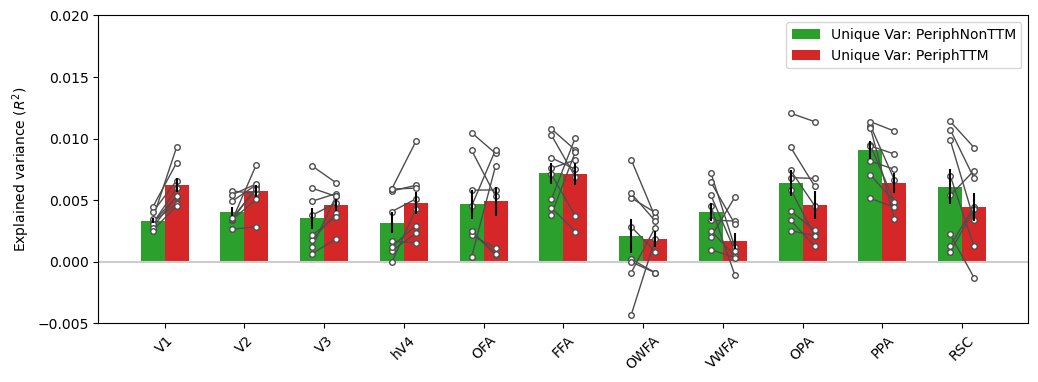

In [12]:
# rndseed = 9978989
# 
jitters = np.linspace(-0.15, 0.15, 2)
width = (jitters[1]-jitters[0])*1.0

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes = [axes]
pi = 0

lh = []

varpart_names = ['Unique Var: %s'%model1_short,'Unique Var: %s'%model2_short,'shared']

for xx, varname in enumerate(varpart_names[0:2]):

    v = var_vals[:,:,xx]
    
    m = np.mean(v, axis=0)
    s = np.std(v, axis=0) / np.sqrt(n_subjects)

    h = axes[pi].bar(np.arange(n_rois)+jitters[xx], m, width = width, color=varpart_colors[xx,:])
    lh += [h]
    
    axes[pi].errorbar(np.arange(n_rois)+jitters[xx], m, yerr=s, color='k', linestyle='none', zorder=10)


for ri in range(n_rois):

    mcolor = [0.3, 0.3, 0.3]
    axes[pi].plot(ri+jitters, var_vals[:,ri,0:2].T, '-', color=mcolor,lw=1.0, zorder=8)
    axes[pi].plot(ri+jitters, var_vals[:,ri,0:2].T, 'o', color='w',markeredgecolor=mcolor,markersize=4, zorder=8)
    
    # vals = var_vals[:,ri,0:2]
    # axes[pi].plot(ri+jitters, vals.T, '.-', color=[0.8, 0.8, 0.8], zorder=8)

    # rndseed+=1
    # vals1 = vals[:,0]
    # vals2 = vals[:,1]
    # pval_twotailed, real_t = \
    #     stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)

    # if pval_twotailed < 0.01:
    #     plt.plot(ri+np.mean(jitters), np.max(vals)+0.001, '*', color='k')

axes[pi].legend(lh, varpart_names[0:2])

axes[pi].set_ylabel('Explained variance ($R^2$)')
axes[pi].set_xticks(np.arange(n_rois), roi_names, rotation=45);
axes[pi].set_ylim([-0.005, 0.020])
axes[pi].axhline(0, color=[0.8, 0.8, 0.8])

fn2save = os.path.join(figpath, 'Varpart_%s_vs_%s_bars.pdf'%(model1_short, model2_short))
print(fn2save)

plt.savefig(fn2save)

In [15]:

print('%s vs. %s'%(model1_name, model2_name))

rndseed=567767

tvals = np.zeros((n_rois,))
pvals = np.zeros((n_rois,))
nsame = np.zeros((n_rois,),dtype=int)
nsubs = np.zeros((n_rois,),dtype=int)
unvar_1 = np.zeros((n_rois,))
unvar_2 = np.zeros((n_rois,))

for ri in range(n_rois):

    vals1 = var_vals[:,ri,0]
    vals2 = var_vals[:,ri,1]

    vals1 = vals1[~np.isnan(vals1)]
    vals2 = vals2[~np.isnan(vals2)]

    unvar_1[ri] = np.mean(vals1)
    unvar_2[ri] = np.mean(vals2)

    rndseed+=1
    pval_twotailed, real_t = \
        stats_utils.paired_ttest_nonpar(vals1, vals2, n_iter=10000, rndseed=rndseed)
    tvals[ri] = real_t
    pvals[ri] = pval_twotailed

    diff_sign = vals1>vals2
    nsame[ri] = int(np.max([np.sum(diff_sign==0), np.sum(diff_sign==1)]))
    nsubs[ri] = len(vals1)
    
df = pd.DataFrame({'unique %s'%(model1_short): unvar_1, \
                   'unique %s'%(model2_short): unvar_2,
                   't': tvals, \
                   'p': pvals, \
                   'sig': ['*' if p<0.01 else '' for p in pvals ], \
                   'n subs same dir': nsame, \
                   'n subs total': nsubs}, index=roi_names)
df

resnet18-PeriphNonTTM vs. resnet18-PeriphTTM


,unique PeriphNonTTM,unique PeriphTTM,t,p,sig,n subs same dir,n subs total
V1,0.003341,0.006223,-6.047919,0.0090,*,8,8
V2,0.004085,0.005742,-3.150164,0.0146,,7,8
V3,0.003536,0.004612,-1.802297,0.1026,,6,8
hV4,0.003188,0.004772,-2.708835,0.0224,,7,8
OFA,0.004678,0.004903,-0.168179,0.8854,,5,8
FFA,0.007194,0.007120,0.060981,0.9396,,5,8
OWFA,0.002113,0.001838,0.224155,0.8244,,6,8
VWFA,0.004063,0.001689,2.139670,0.0684,,7,8
OPA,0.006440,0.004617,3.793519,0.0070,*,8,8
PPA,0.009069,0.006405,2.994411,0.0068,*,8,8


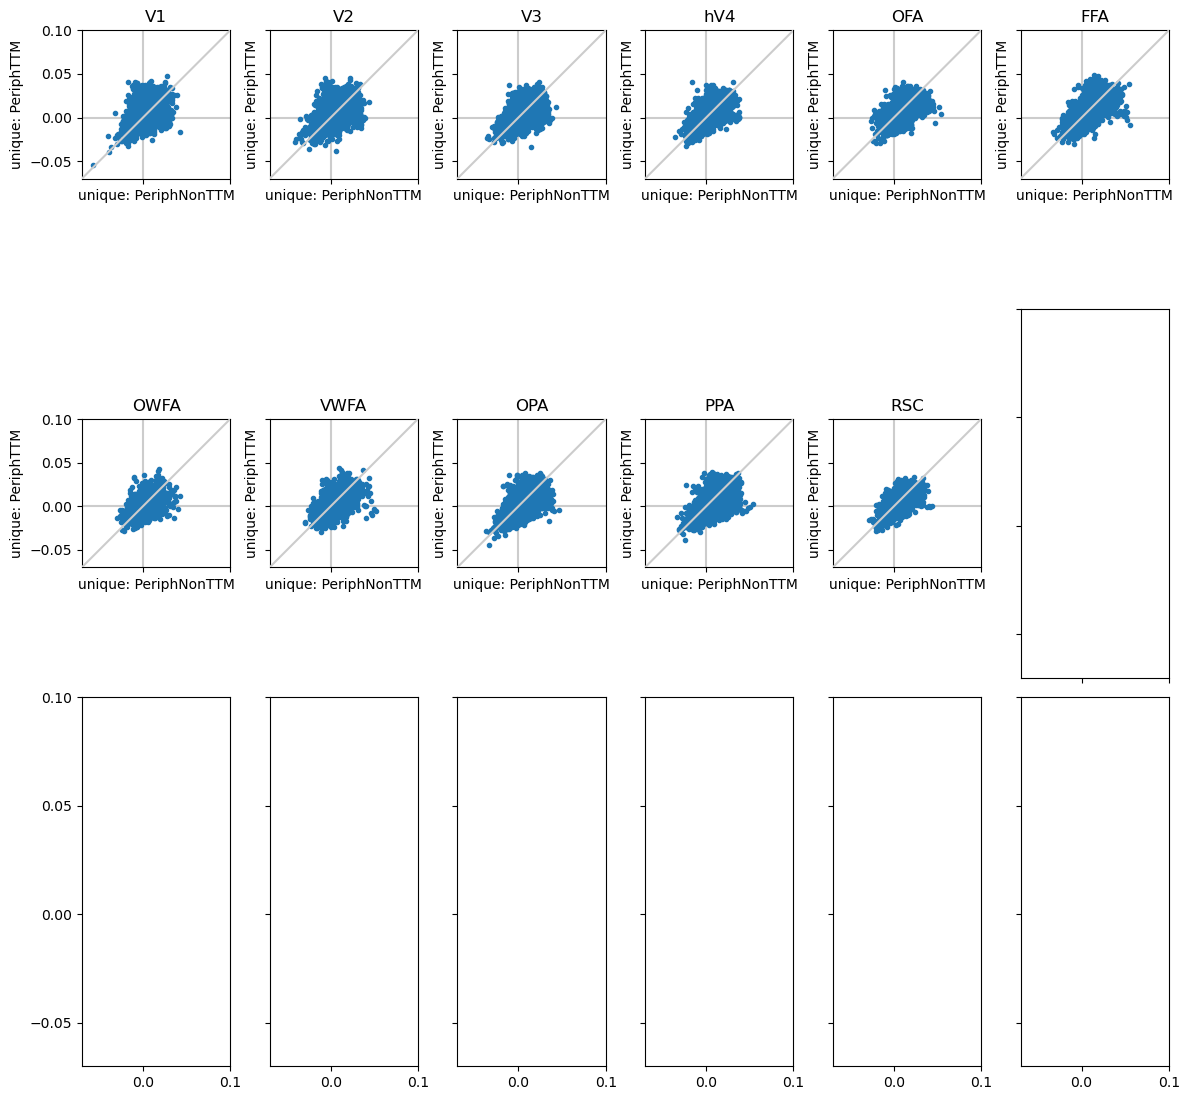

In [16]:

name = model_names[0]

r2_model1 = np.concatenate([fits[name][ss]['unique1'] for ss in subjects], axis=0)
r2_model2 = np.concatenate([fits[name][ss]['unique2'] for ss in subjects], axis=0)

nc = np.concatenate([fits[name][ss]['voxel_nc'] for ss in subjects], axis=0) / 100

limits = [-0.07, 0.10]
# ticks = [0, 0.4, 0.8]

fig, axes = plt.subplots(3, 6, sharex = True, sharey = True, figsize=(12,12))
axes = axes.flatten()

pi=-1

for ri, roi_name in enumerate(roi_names):

    roi_inds = np.concatenate([get_roi_vox(ss, \
                                               roi_name = roi_name,\
                                               floc_thresh = 2) for ss in subjects], axis=0)

    roi_inds = roi_inds & (nc>0.10)

    x = r2_model1[roi_inds]
    y = r2_model2[roi_inds]
    
    pi = pi+1

    axes[pi].plot(x, y, '.', alpha=1.0)
    axes[pi].plot(limits, limits, color=[0.8, 0.8, 0.8], zorder=10)
    axes[pi].axvline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    axes[pi].axhline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    
    axes[pi].set_aspect('equal')

    axes[pi].set_title(roi_name)

    axes[pi].set_xlim(limits)
    axes[pi].set_ylim(limits)

    # axes[pi].set_xticks(ticks)
    # axes[pi].set_yticks(ticks)
    
    axes[pi].set_xlabel('unique: %s'%model1_short)
    axes[pi].set_ylabel('unique: %s'%model2_short)

plt.tight_layout()

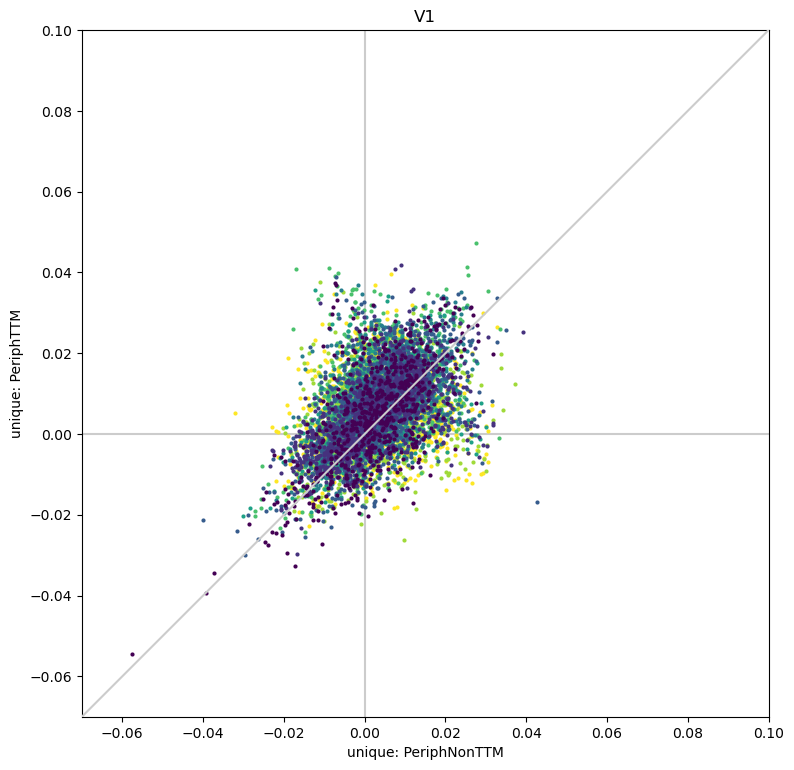

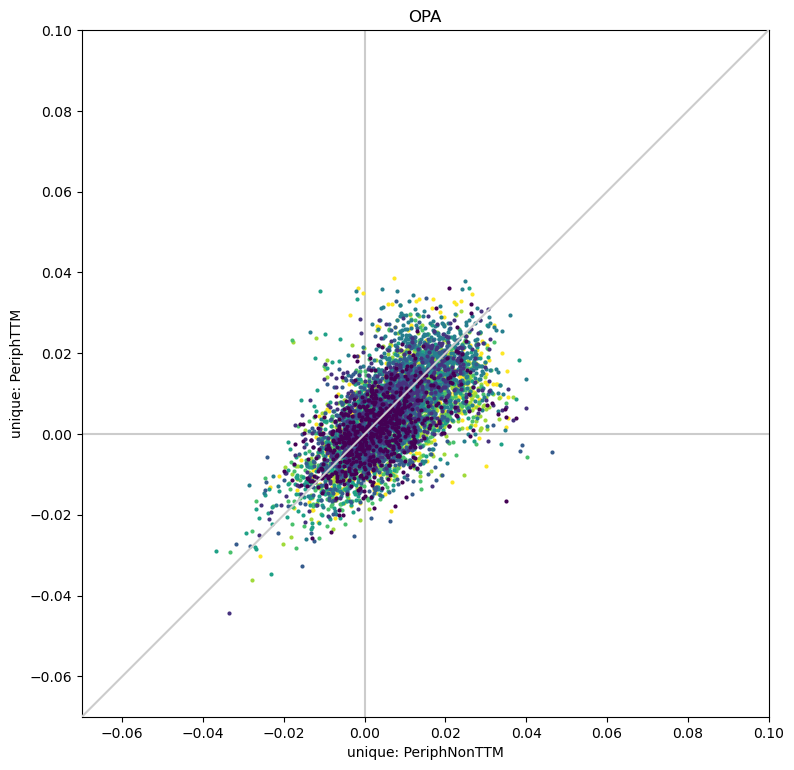

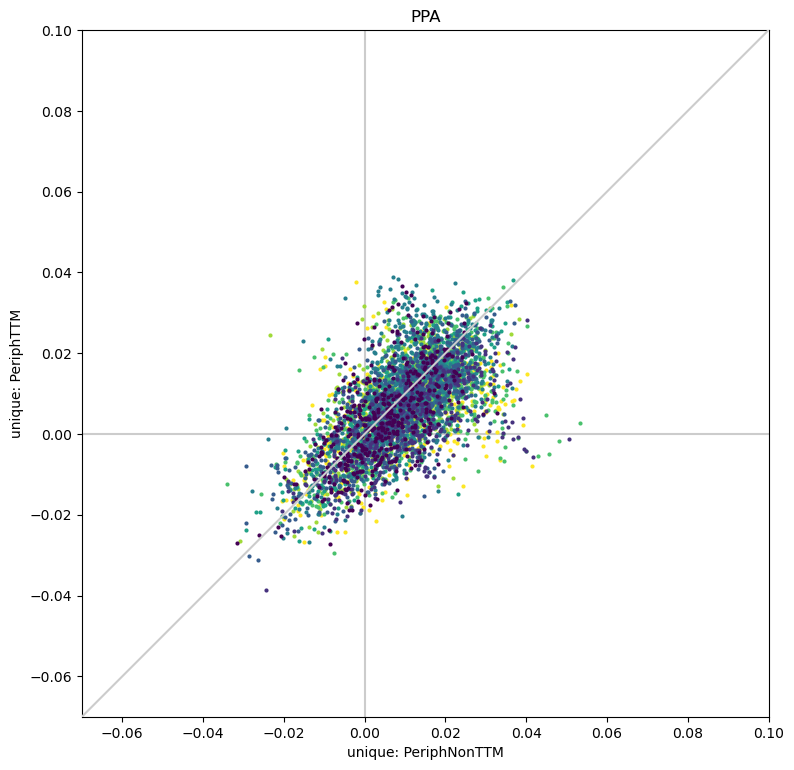

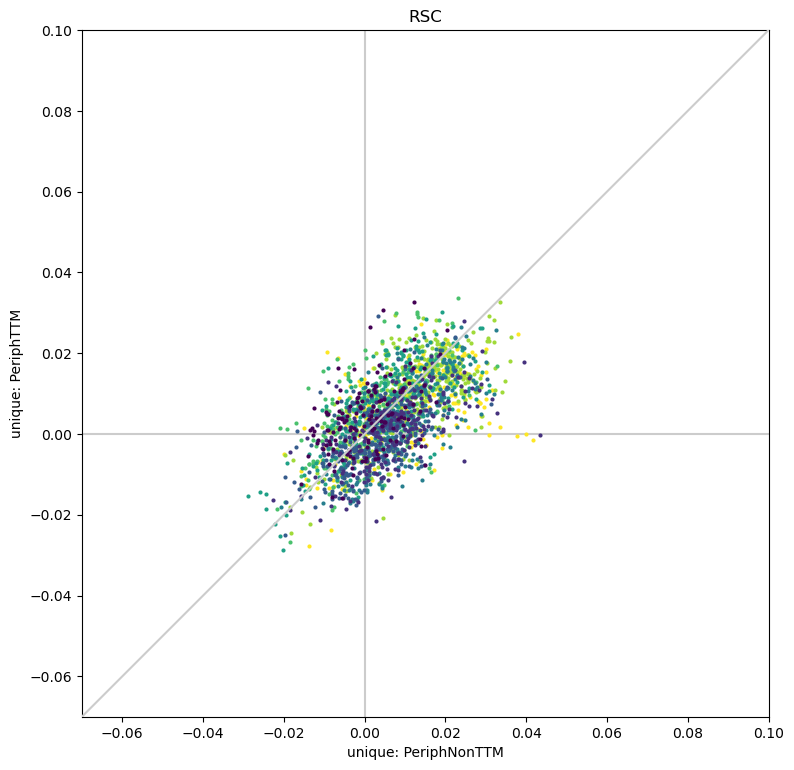

In [21]:
ri = 0


name = model_names[0]

subcolors = np.flipud(cm.viridis(np.linspace(0,1,8)))

limits = [-0.07, 0.10]
# ticks = [0, 0.4, 0.8]


for roi_name in ['V1','OPA','PPA','RSC']:

    fig, axes = plt.subplots(1,1, sharex = True, sharey = True, figsize=(8,8))
    # fig, axes = plt.subplots(2, 6, sharex = True, sharey = True, figsize=(12,8))
    # axes = axes.flatten()
    axes = [axes]
    
    pi=0
    
    for si, ss in enumerate(subjects):
    
        
        r2_model1 = fits[name][ss]['unique1'] 
        r2_model2 = fits[name][ss]['unique2']
        
        nc = fits[name][ss]['voxel_nc'] / 100
        
        
        roi_inds = get_roi_vox(ss, roi_name = roi_name, floc_thresh = 2) 
        
        roi_inds = roi_inds & (nc>0.10)
        
        x = r2_model1[roi_inds]
        y = r2_model2[roi_inds]
        
        axes[pi].plot(x, y, '.', color=subcolors[si], alpha=1.0, markeredgecolor='none')
    
        # meanx = np.mean(x)
        # meany = np.mean(y)
    
        # axes[pi].plot(meanx, meany, '.', color=subcolors[si], alpha=1.0, markersize=10)
    
        
    axes[pi].plot(limits, limits, color=[0.8, 0.8, 0.8], zorder=10)
    axes[pi].axvline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    axes[pi].axhline(0,color=[0.8, 0.8, 0.8], zorder=-10)
    
    axes[pi].set_aspect('equal')
    
    axes[pi].set_title(roi_name)
    
    axes[pi].set_xlim(limits)
    axes[pi].set_ylim(limits)
    
    # axes[pi].set_xticks(ticks)
    # axes[pi].set_yticks(ticks)
    
    axes[pi].set_xlabel('unique: %s'%model1_short)
    axes[pi].set_ylabel('unique: %s'%model2_short)
    
    plt.tight_layout()